In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
movies = pd.read_csv("data/movies.csv")
ratings = pd.read_csv("data/ratings.csv")

print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)

Movies Shape: (9742, 3)
Ratings Shape: (100836, 4)


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
print("Movies Missing Values")
print(movies.isnull().sum())

print("\nRatings Missing Values")
print(ratings.isnull().sum())

Movies Missing Values
movieId    0
title      0
genres     0
dtype: int64

Ratings Missing Values
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


No missing values were found in the movies and ratings datasets.

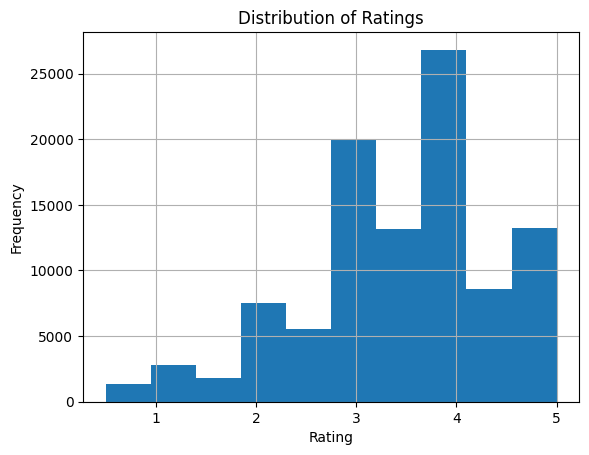

In [9]:
ratings["rating"].hist(bins=10)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

Most ratings are concentrated between 3 and 5, indicating generally positive user feedback.

In [10]:
movie_ratings = pd.merge(
    ratings,
    movies,
    on="movieId"
)

movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [13]:
movie_stats = movie_ratings.groupby(
    "title"
)["rating"].agg(["mean", "count"])

movie_stats.head()

,mean,count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [14]:
movie_stats.sort_values(
    "count",
    ascending=False
).head(10)

,mean,count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224


Popular movies receive significantly more ratings than most other movies.

In [16]:
movie_stats[
    movie_stats["count"] > 50
].sort_values(
    "mean",
    ascending=False
).head(10)

,mean,count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


A minimum rating count threshold was applied to avoid bias from movies with very few ratings.

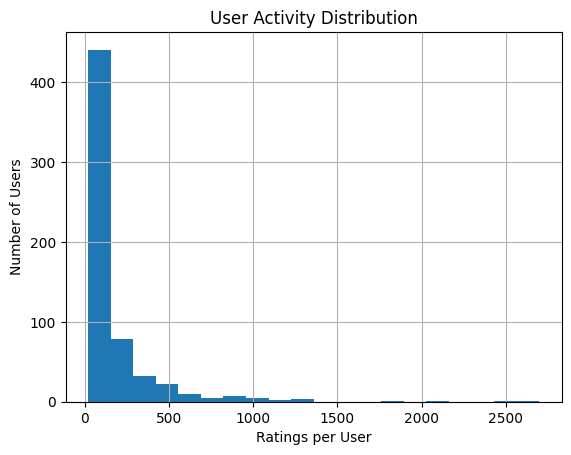

In [18]:
user_activity = ratings.groupby(
    "userId"
)["rating"].count()

user_activity.hist(bins=20)

plt.title("User Activity Distribution")
plt.xlabel("Ratings per User")
plt.ylabel("Number of Users")

plt.show()

In [22]:
user_movie_matrix = movie_ratings.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)
total_cells = (
    user_movie_matrix.shape[0]
    * user_movie_matrix.shape[1]
)

filled_cells = user_movie_matrix.count().sum()

sparsity = (
    1 - filled_cells / total_cells
) * 100

print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 98.30%


The matrix is highly sparse, which is typical in recommendation systems and motivates the use of collaborative filtering techniques.

### Key Findings

- The dataset contains movie metadata and user ratings.
- Ratings are concentrated between 3 and 5.
- Movie popularity is highly skewed.
- User activity varies significantly.
- The user-movie matrix is highly sparse.
- These characteristics make collaborative filtering a suitable recommendation approach.